In [3]:
#!/usr/bin/env python3

# Menyesuaikan path agar dapat mengimpor modul dari direktori utama (induk)
# tanpa mengubah struktur direktori proyek
import sys
sys.path.append('..')

# Mengimpor file module untuk melakukan sync semua file
# pada direktori utama (induk)
import module

Melakukan deteksi fase frame apex dan melakukan validasi menggunakan dataset SAMM

In [4]:
import os
from pathlib import Path


# Sumber utama dataset SAMM
BASE_SAMM_DATASET_PATH = os.path.join(Path.home(), "datasets", "secondaries", "samm")

# Memastikan direktori dataset SAMM ada
assert os.path.exists(BASE_SAMM_DATASET_PATH), f"Dataset SAMM tidak ditemukan di {BASE_SAMM_DATASET_PATH}"

# Memastikan anotasi SAMM ada
ANNOTATIONS_SAMM_PATH = os.path.join(BASE_SAMM_DATASET_PATH, "annotations.xlsx")

# Memastikan file anotasi SAMM ada
assert os.path.exists(ANNOTATIONS_SAMM_PATH), f"Anotasi SAMM tidak ditemukan di {ANNOTATIONS_SAMM_PATH}"

print("Datasource set successfully.")

Datasource set successfully.


Mengambil magnitudo dari sample rentang temporal

In [14]:
import os
import glob


# Mendefinisikan path untuk cerita temporal 006_1_2
SUB_006_006_1_2 = os.path.join(BASE_SAMM_DATASET_PATH, "006", "006_1_2")

# Mendapatkan semua file dalam cerita temporal 006_1_2
SUB_006_006_1_2_FILES = glob.glob(os.path.join(SUB_006_006_1_2, "*"))

# Mendefinisikan path untuk cerita temporal 006_1_3
SUB_006_006_1_3 = os.path.join(BASE_SAMM_DATASET_PATH, "006", "006_1_3")

# Mendapatkan semua file dalam cerita temporal 006_1_3
SUB_006_006_1_3_FILES = glob.glob(os.path.join(SUB_006_006_1_3, "*"))


# Memastikan ada file yang ditemukan dalam cerita temporal 006_1_2
assert len(SUB_006_006_1_2_FILES) > 0, f"Tidak ada file ditemukan di {SUB_006_006_1_2}"

assert len(SUB_006_006_1_3_FILES) > 0, f"Tidak ada file ditemukan di {SUB_006_006_1_3}"

print("Temporal sample 006_1_2 files found successfully.")

Temporal sample 006_1_2 files found successfully.


Melakukan crop daerah wajah dan beberapa area utama seperti alis, mata, dan bibir

W0000 00:00:1770302024.860340   11029 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1770302024.864670   11030 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1770302024.874327   11034 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


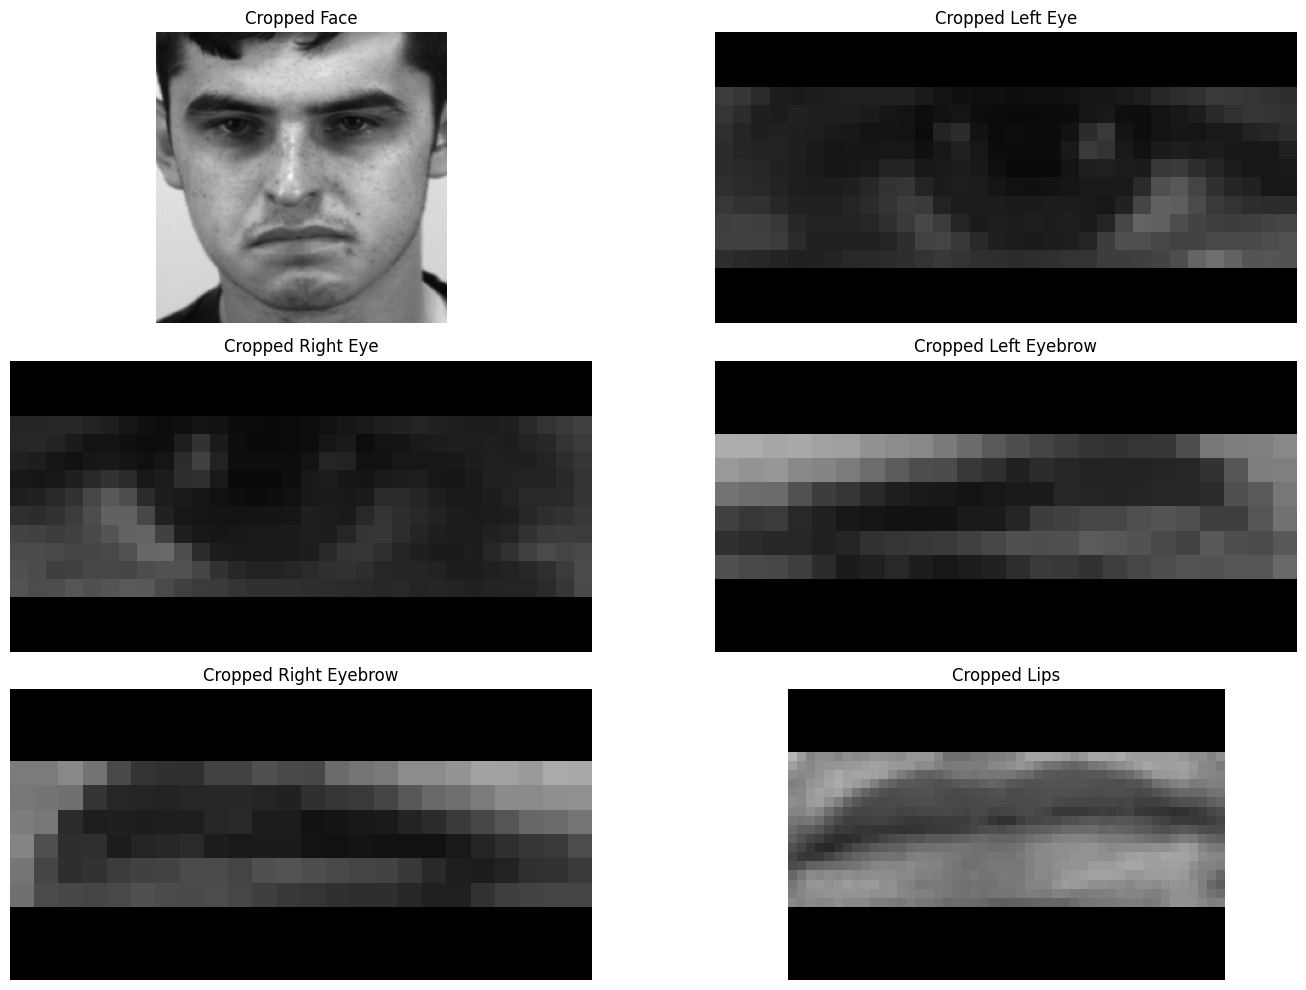

In [15]:
import cv2
import matplotlib.pyplot as plt 
from src.face.modules import FaceLandmark, FaceRoiPoints, FaceRoiSizes


face_landmark = FaceLandmark()

# Mengambil gambar pertama dari cerita temporal 006_1_2
sample_image = cv2.imread(SUB_006_006_1_2_FILES[0])

# Melakukan deteksi wajah dan mendapatkan titik landmark
landmarks = face_landmark.detect(sample_image)

# Memotong wajah dari gambar menggunakan titik landmark yang terdeteksi
face = face_landmark.crop(sample_image.copy(), landmarks)

# Memotong area utama dari wajah
left_eye, left_eye_mask = face_landmark.crop_roi(image=sample_image.copy(),
                                                 landmark_result=landmarks,
                                                 roi_points=FaceRoiPoints.LEFT_EYE_POINTS,
                                                 target_size=FaceRoiSizes.EYE_SIZE)

right_eye, right_eye_mask = face_landmark.crop_roi(image=sample_image.copy(),
                                                   landmark_result=landmarks,
                                                   roi_points=FaceRoiPoints.RIGHT_EYE_POINTS,
                                                   target_size=FaceRoiSizes.EYE_SIZE)

left_eyebrow, left_eyebrow_mask = face_landmark.crop_roi(image=sample_image.copy(),
                                                         landmark_result=landmarks,
                                                         roi_points=FaceRoiPoints.LEFT_EYEBROW_POINTS,
                                                         target_size=FaceRoiSizes.EYEBROW_SIZE)

right_eyebrow, right_eyebrow_mask = face_landmark.crop_roi(image=sample_image.copy(),
                                                           landmark_result=landmarks,
                                                           roi_points=FaceRoiPoints.RIGHT_EYEBROW_POINTS,
                                                           target_size=FaceRoiSizes.EYEBROW_SIZE)

lips, lips_mask = face_landmark.crop_roi(image=sample_image.copy(),
                                         landmark_result=landmarks,
                                         roi_points=FaceRoiPoints.LIPS_POINTS,
                                         target_size=FaceRoiSizes.LIPS_SIZE)

fig, ax = plt.subplots(3, 2, figsize=(15, 10))

ax[0, 0].imshow(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
ax[0, 0].set_title("Cropped Face")
ax[0, 0].axis('off')

ax[0, 1].imshow(cv2.cvtColor(left_eye, cv2.COLOR_BGR2RGB))
ax[0, 1].set_title("Cropped Left Eye")
ax[0, 1].axis('off')

ax[1, 0].imshow(cv2.cvtColor(right_eye, cv2.COLOR_BGR2RGB))
ax[1, 0].set_title("Cropped Right Eye")
ax[1, 0].axis('off')

ax[1, 1].imshow(cv2.cvtColor(left_eyebrow, cv2.COLOR_BGR2RGB))
ax[1, 1].set_title("Cropped Left Eyebrow")
ax[1, 1].axis('off')

ax[2, 0].imshow(cv2.cvtColor(right_eyebrow, cv2.COLOR_BGR2RGB))
ax[2, 0].set_title("Cropped Right Eyebrow")
ax[2, 0].axis('off')

ax[2, 1].imshow(cv2.cvtColor(lips, cv2.COLOR_BGR2RGB))
ax[2, 1].set_title("Cropped Lips")
ax[2, 1].axis('off')

plt.tight_layout()
plt.show()

Membuat base blueprint untuk ekstraksi puncak dan juga fase apex

In [9]:
import numpy as np
from scipy.signal import find_peaks


class ApexPhase:

    # Ambang batas yang digunakan untuk menentukan jarak antar titik puncak
    DISTANCE_THRESHOLD = 5

    # Ambang batas yang digunakan untuk menentukan keunggulan puncak
    PROMINENCE_THRESHOLD = 0.01

    # Ambang batas yang digunakan untuk menentukan lebar fase puncak
    PEAK_CUTOFF_THRESHOLD = 0.35

    def __init__(self,
                 distance_threshold: int = DISTANCE_THRESHOLD,
                 prominence_threshold: float = PROMINENCE_THRESHOLD) -> None:

        self.distance = distance_threshold
        self.prominence = prominence_threshold


    def find_apex(self, signal: list) -> list:
        """
        Mendeteksi titik puncak (apex) dalam sinyal menggunakan metode find_peaks dari scipy.

        Args:
            signal (list): Sinyal input yang akan dianalisis.

        Returns:
            list: Indeks titik puncak yang terdeteksi dalam sinyal.
        """
        peaks, _ = find_peaks(signal,
                              distance=self.distance,
                              prominence=self.prominence)
        return peaks.tolist()
    

    def find_phase(self, signal: list, apex_indices: list) -> dict:
        """
        Mendeteksi fase apex berdasarkan sinyal dan indeks apex yang sudah ditemukan
        
        Args:
            signal (list): Sinyal input yang akan diproses.
            apex_indices (list): Daftar indeks apex yang sudah ditemukan.

        Returns:
            dict: Kamus yang berisi informasi fase apex.
        """
        phases = {}

        for idx, apex_index in enumerate(apex_indices):

            left_bound = 0 if idx == 0 else (apex_indices[idx - 1] + apex_index) // 2
            right_bound = len(signal) - 1 if idx == len(apex_indices) - 1 else (apex_index + apex_indices[idx + 1]) // 2

            start_index, end_index = self.__find_phase_boundaries(signal=signal,
                                                                  apex_index=apex_index,
                                                                  cutoff_ratio=self.PEAK_CUTOFF_THRESHOLD,
                                                                  left_bound=left_bound,
                                                                  right_bound=right_bound)

            phases[apex_index] = dict(start=start_index, end=end_index)

        return phases


    def __find_phase_boundaries(self,
                                signal: list,
                                apex_index: int,
                                cutoff_ratio: float,
                                left_bound: int = 0,
                                right_bound: int = None) -> tuple:
        """
        Mendeteksi batas fase apex berdasarkan sinyal, indeks apex, dan rasio cutoff.

        Args:
            signal (list): Sinyal input yang akan dianalisis.
            apex_index (int): Indeks titik apex dalam sinyal.
            cutoff_ratio (float): Rasio cutoff untuk menentukan batas fase.
            left_bound (int): Batas kiri pencarian (mencegah tumpang tindih).
            right_bound (int): Batas kanan pencarian (mencegah tumpang tindih).

        Returns:
            tuple: Indeks batas awal dan akhir fase apex.
        """
        if right_bound is None:
            right_bound = len(signal) - 1

        apex_value = signal[apex_index]

        local_min = min(np.min(signal[left_bound:apex_index + 1]),
                        np.min(signal[apex_index:right_bound + 1]))

        threshold = local_min + (apex_value - local_min) * cutoff_ratio

        onset_index = left_bound
        for i in range(apex_index, left_bound, -1):
            if signal[i] <= threshold:
                onset_index = i
                break

        offset_index = right_bound
        for i in range(apex_index, right_bound + 1):
            if signal[i] <= threshold:
                offset_index = i
                break

        return onset_index, offset_index


In [19]:
import matplotlib.pyplot as plt


class ApexPhaseVisualizer:

    def plot_phases(self,
                    signal: list,
                    apex_indices: list,
                    phases: dict,
                    title: str = "Apex Phases Visualization") -> None:
        """
        Memvisualisasikan sinyal dengan titik apex dan fase apex yang terdeteksi.

        Args:
            signal (list): Sinyal input yang akan divisualisasikan.
            apex_indices (list): Daftar indeks apex yang sudah ditemukan.
            phases (dict): Kamus yang berisi informasi fase apex.
            title (str): Judul grafik.
        """

        _, axes = plt.subplots(figsize=(12, 6))

        axes.plot(signal, label='Signal', color='blue')

        for apex_index in apex_indices:
            axes.plot(apex_index, signal[apex_index], 'ro', label='Apex' if apex_index == apex_indices[0] else "")

            phase = phases[apex_index]
            axes.axvspan(phase['start'], phase['end'], color='orange', alpha=0.3, label='Apex Phase' if apex_index == apex_indices[0] else "")

        axes.set_title(title)
        axes.set_xlabel('Frame Index')
        axes.set_ylabel('Signal Value')
        axes.legend()
        plt.show()


    def plot_phases_with_actual(self,
                                signal: list,
                                apex_indices: list,
                                phases: dict,
                                actual_phases: dict,
                                title: str = "Apex Phases vs Actual Phases") -> None:
        """
        Memvisualisasikan sinyal dengan titik apex, fase apex yang terdeteksi, dan fase aktual.

        Args:
            signal (list): Sinyal input yang akan divisualisasikan.
            apex_indices (list): Daftar indeks apex yang sudah ditemukan.
            phases (dict): Kamus yang berisi informasi fase apex.
            actual_phases (dict): Kamus yang berisi informasi fase aktual.
            title (str): Judul grafik.
        """

        _, axes = plt.subplots(figsize=(12, 6))

        # Plot sinyal dan apex points yang terdeteksi
        axes.plot(signal, label='Signal', color='blue')
        axes.scatter(apex_indices, [signal[i] for i in apex_indices], color='red', label='Detected Apex Points')

        # Plot fase yang terdeteksi dengan area berwarna hijau
        for apex_index, phase in phases.items():
            axes.axvspan(phase['start'], phase['end'], color='green', alpha=0.3, 
                    label='Detected Phase' if apex_index == apex_indices[0] else "")

        # Plot fase yang sebenarnya dengan garis vertikal
        axes.axvline(actual_phases['onset'], color='orange', linestyle='--', linewidth=2, label='Actual Onset')
        axes.axvline(actual_phases['apex'], color='red', linestyle='--', linewidth=2, label='Actual Apex')
        axes.axvline(actual_phases['offset'], color='purple', linestyle='--', linewidth=2, label='Actual Offset')

        # Tambahkan area berwarna kuning untuk fase yang sebenarnya
        axes.axvspan(actual_phases['onset'], actual_phases['offset'], color='yellow', alpha=0.2, label='Actual Phase')

        axes.legend()
        axes.set_title(title)
        axes.set_xlabel("Frame Index")
        axes.set_ylabel("Optical Flow Magnitude")
        axes.grid(True, alpha=0.3)

        plt.show()

Mengambil magnitudo dari keseluruhan wajah dan juga mengambil fase apexnya

W0000 00:00:1770333954.813021   22645 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1770333954.818027   22647 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1770333954.826552   22657 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


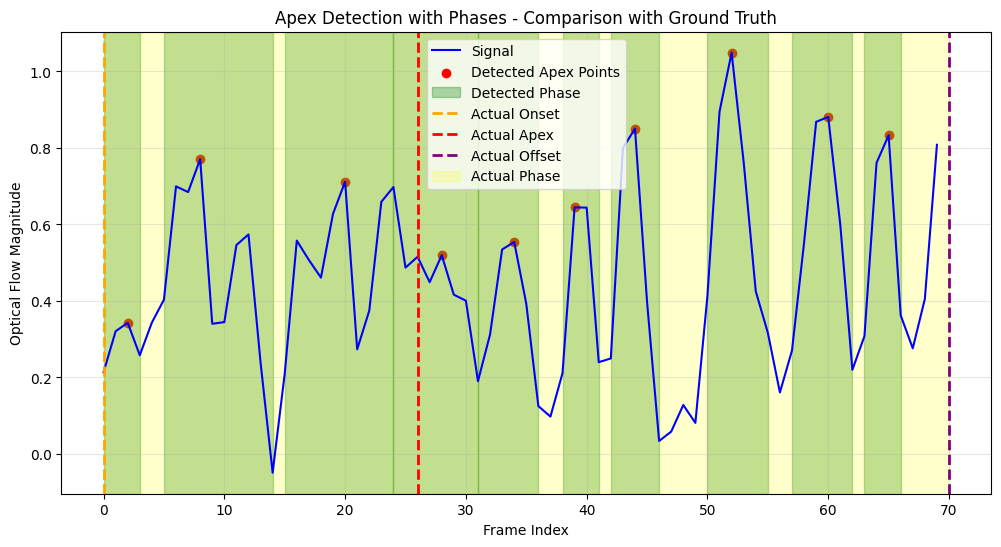

In [ ]:
import cv2
import numpy as np
from scipy.signal import savgol_filter
from src.face.modules import FaceLandmark
from src.optical_flow.modules import TVL1


magnitudes = []

face_landmark = FaceLandmark()

tvl1 = TVL1()

apex_phase = ApexPhase()

for index in range(len(SUB_006_006_1_2_FILES) - 1):
    
    prev_image = cv2.imread(SUB_006_006_1_2_FILES[index])
    next_image = cv2.imread(SUB_006_006_1_2_FILES[index + 1])

    landmarks = face_landmark.detect(prev_image)

    face_prev = face_landmark.crop(image=prev_image.copy(), landmarks=landmarks)
    face_next = face_landmark.crop(image=next_image.copy(), landmarks=landmarks)

    flow = tvl1.compute(face_prev, face_next)

    dx = flow[..., 0]
    dy = flow[..., 1]

    magnitude = np.sqrt(dx**2 + dy**2)

    mean_magnitude = np.mean(magnitude)

    magnitudes.append(mean_magnitude)


smooted_magnitudes = savgol_filter(magnitudes, window_length=5, polyorder=2)

apex_indices = apex_phase.find_apex(smooted_magnitudes)

phases = apex_phase.find_phase(signal=smooted_magnitudes, apex_indices=apex_indices)

actual_phase = dict(onset=0, apex=26, offset=70)

apex_phase_visualizer = ApexPhaseVisualizer()

apex_phase_visualizer.plot_phases_with_actual(signal=smooted_magnitudes,
                                              apex_indices=apex_indices,
                                              phases=phases,
                                              actual_phases=actual_phase,
                                              title="Apex Detection with Phases - Comparison with Ground Truth")

W0000 00:00:1770334002.982030   22764 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1770334002.987222   22768 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1770334002.997420   22776 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


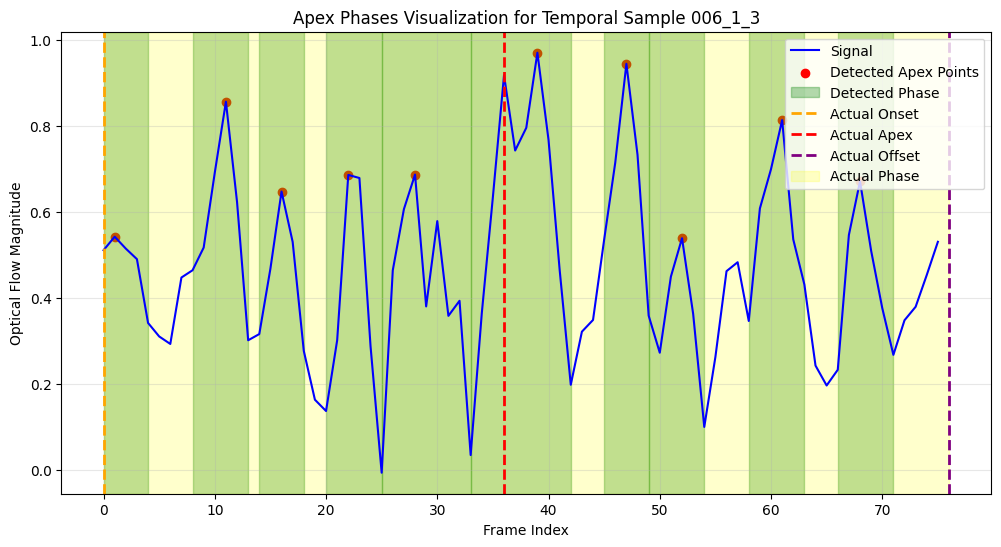

In [27]:
import cv2
import numpy as np
from scipy.signal import savgol_filter
from src.face.modules import FaceLandmark
from src.optical_flow.modules import TVL1


magnitudes = []

face_landmark = FaceLandmark()

tvl1 = TVL1()

apex_phase = ApexPhase()

for index in range(len(SUB_006_006_1_3_FILES) - 1):
    
    prev_image = cv2.imread(SUB_006_006_1_3_FILES[index])
    next_image = cv2.imread(SUB_006_006_1_3_FILES[index + 1])

    landmarks = face_landmark.detect(prev_image)

    face_prev = face_landmark.crop(image=prev_image.copy(), landmarks=landmarks)
    face_next = face_landmark.crop(image=next_image.copy(), landmarks=landmarks)

    flow = tvl1.compute(face_prev, face_next)

    dx = flow[..., 0]
    dy = flow[..., 1]

    magnitude = np.sqrt(dx**2 + dy**2)

    mean_magnitude = np.mean(magnitude)

    magnitudes.append(mean_magnitude)


smooted_magnitudes = savgol_filter(magnitudes, window_length=5, polyorder=2)

apex_indices = apex_phase.find_apex(smooted_magnitudes)

phases = apex_phase.find_phase(signal=smooted_magnitudes, apex_indices=apex_indices)

actual_phase = dict(onset=0, apex=36, offset=76)

apex_phase_visualizer = ApexPhaseVisualizer()

apex_phase_visualizer.plot_phases_with_actual(signal=smooted_magnitudes,
                                              apex_indices=apex_indices,
                                              phases=phases,
                                              actual_phases=actual_phase,
                                              title="Apex Phases Visualization for Temporal Sample 006_1_3")